<a href="https://colab.research.google.com/github/Kavia-M/Data_science_course-Intellipaat/blob/main/Python/Assignments/Assignment_Quiz/LDA_Assignment_Quiz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Problem Statement:**

You have been provided with a multi dimensional data that contains information on certain images. Using machine learning, you should be able to predict the images on the new set of data using the model that you have trained on the existing data.

**Dataset Information:**

Each point in the data is an 8×8 image.

|                 |             |
|-----------------|-------------|
| Classes         | 10          |
| Samples per class | ~180      |
| Samples total   | 1797        |
| Dimensionality  | 64          |
| Features        | integers 0-16|



**Note: Load the dataset from sklearn.datasets.load_digits()**

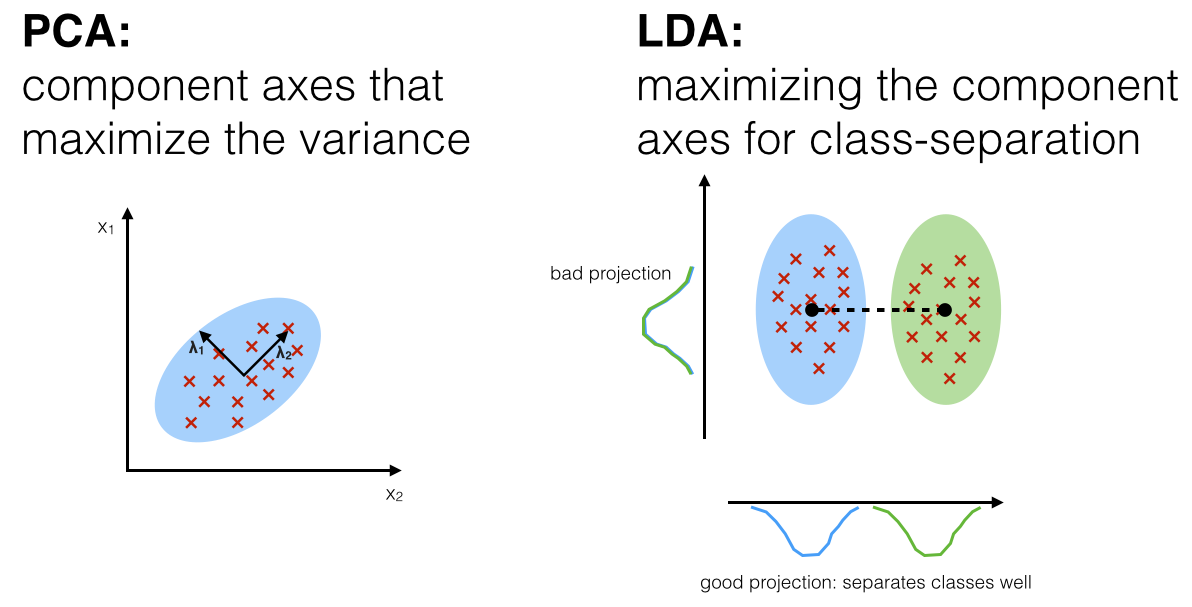

LDA is supervised and for classification problems

LDA tries to find directions(new axes) that separates different classes as much as possible

The datasets are digits (already used in PCA Assignment Quiz) and pokemon.csv (already used in Decision Tree Assignment Quiz)

1) What will be the output of the following code?  

```python
from sklearn import dataset  
digits = datasets.load_digits()
```

- Value error
- Digits data in a pandas dataframe
- Import error
- Digits data from the sklearn module

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
from sklearn import dataset
digits = datasets.load_digits()

ImportError: cannot import name 'dataset' from 'sklearn' (/usr/local/lib/python3.12/dist-packages/sklearn/__init__.py)

ImportError: cannot import name 'dataset' from 'sklearn'


Import Error is answer

The correct module name in scikit-learn is `datasets`, not `dataset`.

In [2]:
from sklearn import datasets
digits = datasets.load_digits()

In [3]:
# alternative
# from sklearn.datasets import load_digits
# digits=load_digits()

1. Answer - Import error

2) If we split the data in a ratio of 80% training and 20% testing data, what will be the correct code for the same?
- X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=80, random_state=42)
- X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=20, random_state=42)
- X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=80:20, random_state=42)
- X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

[sklearn documentation for train test split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

test_size : If float, should be between 0.0 and 1.0 portion is represented

**If int, represents the absolute number of test samples.**

In [4]:
X_digits = digits.data

In [5]:
X_digits

array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]])

In [6]:
X_digits.size

115008

In [7]:
X_digits.shape

(1797, 64)

In [8]:
y_digits = digits.target

In [9]:
y_digits.shape

(1797,)

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train_digits, X_test_digits, y_train_digits, y_test_digits = train_test_split(X_digits, y_digits, test_size=80, random_state=42)

In [12]:
X_train_digits.shape

(1717, 64)

In [13]:
X_test_digits.shape

(80, 64)

test_size=80 is wrong, this is not 80% but 80 rows itself. That too 80 is test rows number not train rows number

In [14]:
X_train_digits, X_test_digits, y_train_digits, y_test_digits = train_test_split(X_digits, y_digits, test_size=20, random_state=42)

In [15]:
X_train_digits.shape

(1777, 64)

In [16]:
X_test_digits.shape

(20, 64)

test_size=20 is wrong. 20 is number of rows in test data not 20%

In [17]:
X_train_digits, X_test_digits, y_train_digits, y_test_digits = train_test_split(X_digits, y_digits, test_size=80:20, random_state=42)

SyntaxError: invalid syntax (ipython-input-3986048509.py, line 1)

test_size=80:20 ratio is not accepted as it is not float or int or even None

In [19]:
X_train_digits, X_test_digits, y_train_digits, y_test_digits = train_test_split(X_digits, y_digits, test_size=0.2, random_state=42)

In [20]:
X_train_digits.shape

(1437, 64)

In [21]:
X_test_digits.shape

(360, 64)

In [22]:
y_train_digits.shape

(1437,)

In [23]:
y_test_digits.shape

(360,)

In [26]:
import math

In [25]:
(X_train_digits.shape[0] / X_test_digits.shape[0])

3.9916666666666667

In [27]:
math.isclose((X_train_digits.shape[0] / X_test_digits.shape[0]), (80/20)) #false because it tolerates 0.000000001 something

False

In [28]:
round(X_train_digits.shape[0] / X_test_digits.shape[0])

4

In [30]:
round(80/20)

4

In [31]:
round(X_train_digits.shape[0] / X_test_digits.shape[0]) == round(80/20)

True

test_size=0.2 is correct this gives train size : test size as 80:20

2. Answer - X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

3) In the train_test_split, if we keep the random_state = 1, what does it mean for our training and testing data?
- None of the Above
- Everytime the new random values are generated in the test and train sets
- The values will be the same every time the code is executed in the testing and training sets.
- Both 1 and 2.

✅ **Correct Answer:**

> **The values will be the same every time the code is executed in the testing and training sets.**

---

##### **Explanation:**

In `train_test_split()` from `sklearn.model_selection`, the parameter `random_state` acts as a **seed for the random number generator**.

* The data is split **randomly** — but **in a reproducible way**.
* Setting `random_state=1` ensures that the **same random split** happens **every time you run the code**.
* If you omit it or change the value, you’ll get **different splits** each time.

---


In [32]:
X_train_digits_31, X_test_digits_31, y_train_digits_31, y_test_digits_31 = train_test_split(X_digits, y_digits, test_size=0.2, random_state=1)

In [33]:
X_train_digits_32, X_test_digits_32, y_train_digits_32, y_test_digits_32 = train_test_split(X_digits, y_digits, test_size=0.2, random_state=1)

In [35]:
np.array_equal(X_train_digits_31, X_train_digits_32)

True

In [36]:
np.array_equal(X_test_digits_31, X_test_digits_32)

True

In [37]:
np.array_equal(y_train_digits_31, y_train_digits_32)

True

In [38]:
np.array_equal(y_test_digits_31, y_test_digits_32)

True

train_test_split(X_digits, y_digits, test_size=0.2, random_state=1)

always the same rows are in train and test split

3. Answer - The values will be the same every time the code is executed in the testing and training sets.

4) In the code below, where we standardize the data, we have used the fit_transform() for the training sample, and transform() for the testing sample, why?

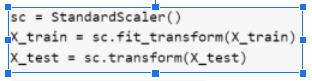

- The methods distinguish between mean and standard deviation of each class.
- None of the above
- We use the same mean and variance calculated on the training data to fit the test data
- The methods distinguish between the variance of each class

✅ **Correct Answer:**

> **We use the same mean and variance calculated on the training data to fit the test data**

---

##### **Explanation:**

When standardizing data using `StandardScaler` (or similar), the goal is to **scale features using statistics from the training set only** — not from the test set.

---

##### **Why this matters:**

* `fit_transform()` →
  Calculates **mean** and **standard deviation** of the given data and then scales it.

* `transform()` →
  Uses **already computed** mean and standard deviation to scale new data.

If you call `fit_transform()` on both train and test sets separately,

➡️ the test data would be standardized using **its own statistics**,

➡️ causing **data leakage** and unrealistic evaluation.

---



If we do:

```python
scaler.fit_transform(whole_X)
```

you are **fitting (learning mean & std)** and **transforming** on the **entire dataset** (train + test combined).

---

##### ⚠️ This causes **data leakage**

Because:

* The scaler computes **mean and standard deviation using all samples**, including those from the **test set**.
* That means information from the **test data** has already influenced the scaling process **before training**.
* When you later split or evaluate, your test data is **no longer truly unseen** — it has indirectly “helped” shape the scaling.

➡️ So, the model evaluation will look better than it really is in real life.

---

fit_transform for train and transform for test. This way:

* **fit()** learns scaling parameters from training data only.
* **transform()** applies the same transformation to test data — without leaking information.

---

##### 🧠 **Summary**

| Operation                | What it does                     | Safe to use on            |
| ------------------------ | -------------------------------- | ------------------------- |
| `fit_transform()`        | Learns mean & std, then scales   | ✅ Training data only      |
| `transform()`            | Uses learned mean & std to scale | ✅ Test (or new) data      |
| `fit_transform(whole_X)` | Uses test data info too          | ❌ Causes **data leakage** |

So yes — `scaler.fit_transform(whole_X)` means the test data is **exposed**, and it’s **not recommended**.


In [39]:
from sklearn.preprocessing import StandardScaler

In [40]:
sc_digits = StandardScaler()

In [41]:
X_train_digits_std = sc_digits.fit_transform(X_train_digits)   # ✅ computes mean & std from training data
X_test_digits_std = sc_digits.transform(X_test_digits)         # ✅ uses training mean & std to scale test data

In [42]:
X_train_digits_std

array([[ 0.        , -0.34169755, -0.46336049, ...,  1.05270303,
         0.45952251, -0.19710003],
       [ 0.        , -0.34169755,  0.78471641, ..., -0.64451929,
        -0.50623083, -0.19710003],
       [ 0.        , -0.34169755, -1.08739895, ..., -0.13535259,
        -0.50623083, -0.19710003],
       ...,
       [ 0.        , -0.34169755,  0.78471641, ...,  1.56186972,
        -0.02335416, -0.19710003],
       [ 0.        , -0.34169755, -0.87938613, ..., -1.15368598,
        -0.50623083, -0.19710003],
       [ 0.        , -0.34169755, -0.87938613, ..., -0.98396375,
        -0.50623083, -0.19710003]])

4. Answer - We use the same mean and variance calculated on the training data to fit the test data

5) Find the mistake in the code below?  

```python
lda = LinearDiscriminantAnalysis(n_components=9)  
X_train = lda.fit_transform(X_train)  
X_test = lda.transform(X_test)
```

- Both 1 and 2
- Fit_transform() must include the y_train.
- None of the above
- transform() must include the y_train.

In [43]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [46]:
lda_digits_9 = LinearDiscriminantAnalysis(n_components=9)

In [47]:
X_train_digits_lda = lda_digits_9.fit_transform(X_train_digits_std)  # missing y
X_test_digits_lda = lda_digits_9.transform(X_test_digits_std)

TypeError: LinearDiscriminantAnalysis.fit() missing 1 required positional argument: 'y'

LinearDiscriminantAnalysis.fit() missing 1 required positional argument: 'y'

in

X_train_digits_lda = lda_digits_9.fit_transform(X_train_digits_std)

In Linear Discriminant Analysis (LDA), unlike PCA, it’s a **supervised dimensionality reduction technique**.
That means it needs both the feature matrix `𝑋`
 and the target labels
`𝑦` to find the directions that best separate the classes.

Why labels are needed in fit_transform:

LDA is supervised — it finds the directions (linear combinations of features) that maximize class separation.

So it must know which data point belongs to which class → that’s y_train.

```python
X_test = lda.transform(X_test)
```

Here, LDA **applies** the transformation **already learned** from the training data.

Why no labels are needed here:

* The transformation (mean vectors, within-class scatter, between-class scatter, projection matrix) was already computed using `X_train` and `y_train`.
* You’re now just **using those learned parameters** to project new data (`X_test`) into the same lower-dimensional space.
* So you **don’t want to use `y_test`** — because y_test would leak test label information into the model.

---

##### 💡 **Summary**

| Step     | Function                          | Requires labels? | Why                                                |
| -------- | --------------------------------- | ---------------- | -------------------------------------------------- |
| Training | `fit_transform(X_train, y_train)` | ✅ Yes            | LDA needs labels to learn class separation         |
| Testing  | `transform(X_test)`               | ❌ No             | Uses already learned transformation, no label info |

---

✅ **In short:**

> `fit_transform()` → learns from **training data + labels**
> `transform()` → applies that learning to **unseen test data (no labels needed)**


In [48]:
# lda = LinearDiscriminantAnalysis(n_components=9)
X_train_digits_lda = lda_digits_9.fit_transform(X_train_digits_std, y_train_digits)  # ✅ include labels
X_test_digits_lda = lda_digits_9.transform(X_test_digits_std)

In [49]:
X_train_digits_lda.shape

(1437, 9)

In [50]:
X_test_digits_lda.shape

(360, 9)

5. Answer - Fit_transform() must include the y_train.

6) Split the data in 80: 20 ratios, then Standardize and perform LDA. What would be the shape of the X_train data, after doing all the mentioned operations?
- (1437,)
- (1437,64)
- (1437,9)
- (1797,64)

Above we have done all steps.

1. train test split 80:20
2. std scalar
3. lda

In [51]:
X_train_digits_lda.shape

(1437, 9)

6. Answer - (1437,9)

7) Which of the following is a common application of LDA?
- Document classification
- All of the above
- Topic modeling of social media data
- Fraud detection

✅ **Correct Answer:**

> **All of the above**

---

##### **Explanation:**

**Linear Discriminant Analysis (LDA)** is mainly used for **dimensionality reduction and supervised classification**, but it also appears in slightly different contexts depending on the field:

1. **Document classification**

   * LDA can be used to **reduce dimensionality of text features** (like TF-IDF vectors) before classification.

2. **Topic modeling of social media data**

   * Note: Here, **LDA usually refers to Latent Dirichlet Allocation**, which is **unsupervised** and different from Linear Discriminant Analysis.
   * But in quizzes, “LDA” is often considered a technique for topic modeling as well.

3. **Fraud detection**

   * LDA is used to **classify transactions** as fraudulent or normal by finding directions that separate the classes.

---

##### 💡 **Summary:**

* LDA is **widely applicable** for classification tasks across domains.
* That’s why **“All of the above”** is the most appropriate choice.


7. Answer - All of the above

8) How do you decide the n_components in the LinearDiscriminantAnalaysis()?
- (no. of classes) -1
- None of the above
- variation inflation factor
- Correlation coefficient

VIF used in Multiple regression

Multiple regression is a statistical technique that analyzes the linear relationship between a single continuous dependent variable and two or more independent variables to understand how the independent variables collectively and individually influence the dependent variable

✅ **Correct Answer:**

> **(number of classes) - 1**

---

###### **Explanation:**

In **Linear Discriminant Analysis (LDA)**:

* LDA tries to find **linear combinations of features** (called **discriminants**) that **maximize class separation**.
* The **maximum number of discriminants** you can get is limited by the **number of classes**:

$
\text{n_components} \le (\text{number of classes} - 1)
$

###### Example:

* If you have **3 classes** → maximum **2 components** (`3 - 1 = 2`)
* If you have **5 classes** → maximum **4 components** (`5 - 1 = 4`)

---

##### ❌ Why not the other options?

* **Variation inflation factor (VIF)** → used to detect **multicollinearity**, unrelated to LDA components.
* **Correlation coefficient** → measures linear correlation between two variables, unrelated to LDA.

---

✅ **Answer:**
**(number of classes) - 1**


Correlation Coefficient and VIF also used as guide to dimensionality reduction but not directly used as PCA or LDA. but correlation coefficient and VIF can help us to see which features to drop (manual feature reduction)

8. Answer - (no. of classes) -1

9) If we keep the n_components as 15 in the LDA, what will be the shape of the X_train data?
- (15,)
- (1797,15)
- (15,15)
- (1437, 15)

In [52]:
X_train_digits_std.shape

(1437, 64)

Assuming if n_components=15, If n_components in LDA is 15 and we pass the above data X_train_digits_15 we get (1437, 15) as resulting shape as number of rows will be same and 15 as number of LDA columns

But this is not possible in code because number of classes in digits is 9 only

n_components cannot be larger than min(n_features, n_classes - 1).

(1797,15) is size of total X data train and test not X_train only

In [53]:
digits.feature_names

['pixel_0_0',
 'pixel_0_1',
 'pixel_0_2',
 'pixel_0_3',
 'pixel_0_4',
 'pixel_0_5',
 'pixel_0_6',
 'pixel_0_7',
 'pixel_1_0',
 'pixel_1_1',
 'pixel_1_2',
 'pixel_1_3',
 'pixel_1_4',
 'pixel_1_5',
 'pixel_1_6',
 'pixel_1_7',
 'pixel_2_0',
 'pixel_2_1',
 'pixel_2_2',
 'pixel_2_3',
 'pixel_2_4',
 'pixel_2_5',
 'pixel_2_6',
 'pixel_2_7',
 'pixel_3_0',
 'pixel_3_1',
 'pixel_3_2',
 'pixel_3_3',
 'pixel_3_4',
 'pixel_3_5',
 'pixel_3_6',
 'pixel_3_7',
 'pixel_4_0',
 'pixel_4_1',
 'pixel_4_2',
 'pixel_4_3',
 'pixel_4_4',
 'pixel_4_5',
 'pixel_4_6',
 'pixel_4_7',
 'pixel_5_0',
 'pixel_5_1',
 'pixel_5_2',
 'pixel_5_3',
 'pixel_5_4',
 'pixel_5_5',
 'pixel_5_6',
 'pixel_5_7',
 'pixel_6_0',
 'pixel_6_1',
 'pixel_6_2',
 'pixel_6_3',
 'pixel_6_4',
 'pixel_6_5',
 'pixel_6_6',
 'pixel_6_7',
 'pixel_7_0',
 'pixel_7_1',
 'pixel_7_2',
 'pixel_7_3',
 'pixel_7_4',
 'pixel_7_5',
 'pixel_7_6',
 'pixel_7_7']

In [54]:
digits.target_names

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [56]:
lda_digits_15 = LinearDiscriminantAnalysis(n_components=15)
X_train_digits_lda_15 = lda_digits_15.fit_transform(X_train_digits_std, y_train_digits)
X_test_digits_lda_15 = lda_digits_15.transform(X_test_digits_std)

ValueError: n_components cannot be larger than min(n_features, n_classes - 1).

9. Answer - (1437, 15)

10) After performing LDA on the standardized data, with n_components= 9, Create a random forest classifier to fit the new data with n_estimators= 100, and random_state =42. After the above operation, what will be the accuracy score of the model?
- 80%
- 85%
- 90 % and above
- 55% to 75%

##### Step 1 - After performing LDA on the standardized data, with n_components= 9

Already done

In [57]:
X_train_digits_lda

array([[-3.58237017, -1.82036205,  3.00354787, ..., -0.19386593,
        -0.50007375,  0.40930703],
       [-1.80100317, -5.22276097, -0.2949643 , ...,  0.0265648 ,
        -0.22963409, -1.04943511],
       [-3.72212375, -4.66452054,  1.38358504, ..., -0.55908754,
         1.49164952,  0.46660897],
       ...,
       [ 4.59583386,  1.78946073,  1.75367091, ..., -0.79933938,
         0.90072478, -0.05667756],
       [-1.68877425,  1.54411725, -2.61837563, ..., -0.84332676,
         0.47515619, -0.06963443],
       [-0.83972348,  1.63212091,  1.49817706, ..., -1.49463464,
         1.92194133,  0.39084073]])

In [58]:
X_train_digits_lda.shape

(1437, 9)

In [59]:
X_test_digits_lda.shape

(360, 9)

In [60]:
y_train_digits.shape

(1437,)

In [61]:
y_test_digits.shape

(360,)

##### Step 2 - Create a random forest classifier to fit the new data with n_estimators= 100, and random_state =42.

In [62]:
from sklearn.ensemble import RandomForestClassifier

In [63]:
rf_digits = RandomForestClassifier(n_estimators=100, random_state=42) # although n_entimators is 100 by default

In [64]:
rf_digits.fit(X_train_digits_lda, y_train_digits)

RandomForestClassifier(random_state=42)

In [65]:
y_pred_digits = rf_digits.predict(X_test_digits_lda)

##### Step 3 - what will be the accuracy score of the model

In [66]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

In [67]:
accuracy_score(y_test_digits, y_pred_digits)

0.9583333333333334

In [68]:
acc_digits_percentage = accuracy_score(y_test_digits, y_pred_digits) * 100

In [69]:
acc_digits_percentage

95.83333333333334

10. Answer - 90 % and above

11)  Identify the mistake in the code below.

```python
from sklearn.ensemble import RandomForestClassifier  
rf = RandomForestClassifier(n_estimators=100, random_state=42)  
rf.fit(X_train, X_test)
```
- X_test instead of n_components = 9
- X_test instead of y_test
- X_test instead of y_train
- Missing parameter - random_state=42

Mistake is **X_test instead of y_train** in the code

As per above question's answer code. y_train that is y_train_digits should be passed along with X_train_digits_lda in rf_digits.fit

Other options : (why not correct)

 n_components = 9 used in LDA or PCA only not in RandomForest

y_test should be used after prediction for accuracy only. Not in fit. Fit should be done on training data only

random_state=42 already there in code. it is not missing

In [70]:
# 1st 2 lines already done
rf_digits.fit(X_train_digits_lda, X_test_digits_lda)

ValueError: Found input variables with inconsistent numbers of samples: [1437, 360]

11. Answer - X_test instead of y_train

12) What percentage of positive cases was the model able to catch for class 6?
- 35
- 100
- 99
- 97

In [71]:
cm_digits = confusion_matrix(y_test_digits, y_pred_digits)

In [72]:
cm_digits

array([[31,  0,  0,  1,  1,  0,  0,  0,  0,  0],
       [ 0, 27,  1,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0, 31,  2,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0, 33,  0,  1,  0,  0,  0,  0],
       [ 0,  0,  0,  0, 46,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  1,  0, 45,  0,  0,  0,  1],
       [ 0,  0,  0,  0,  1,  0, 34,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0, 33,  0,  1],
       [ 0,  2,  0,  0,  0,  0,  0,  0, 27,  1],
       [ 0,  0,  0,  1,  1,  0,  0,  0,  0, 38]])

<Axes: >

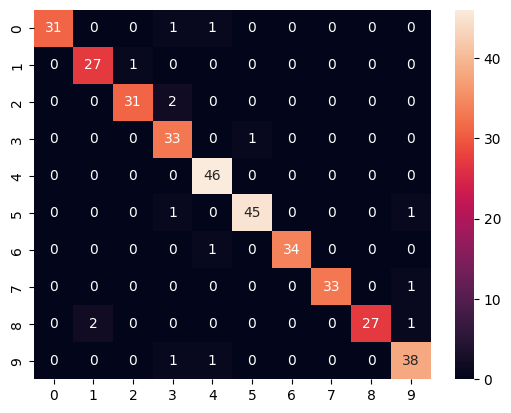

In [73]:
sns.heatmap(cm_digits,annot=True)

Confusion matrix in sklearn: [sklearn confusion matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)

Returns:

C

ndarray of shape (n_classes, n_classes)
Confusion matrix whose i-th row and j-th column entry indicates the number of samples with true label being i-th class and predicted label being j-th class.

In [77]:
# To explain the errors I am converting the confusion matrix which is originally a array to a dataframe
cm_digits_df = pd.DataFrame(cm_digits,columns=range(10),index=range(10))
# the confusion matrix are as follows:
# the columns are predicted and rows are actual:

In [78]:
cm_digits_df

,0,1,2,3,4,5,6,7,8,9
0,31,0,0,1,1,0,0,0,0,0
1,0,27,1,0,0,0,0,0,0,0
2,0,0,31,2,0,0,0,0,0,0
3,0,0,0,33,0,1,0,0,0,0
4,0,0,0,0,46,0,0,0,0,0
5,0,0,0,1,0,45,0,0,0,1
6,0,0,0,0,1,0,34,0,0,0
7,0,0,0,0,0,0,0,33,0,1
8,0,2,0,0,0,0,0,0,27,1
9,0,0,0,1,1,0,0,0,0,38


diagonal is correct predictions

What percentage of positive cases was the model able to catch for class 6 ?

They are asking % not number of correct *predictions*

1️⃣ Confusion matrix structure (for multi-class)

For class
$𝑖$ :


|          | Predicted = i | Predicted ≠ i |
| -------- | ------------- | ------------- |
| True = i | **TP**        | **FN**        |
| True ≠ i | **FP**        | **TN**        |


> “What percentage of positive cases was the model able to catch for class 6?”

* This is **Recall (Sensitivity) for class 6**:
  $
  \text{Recall} = \frac{\text{TP}}{\text{TP + FN}} \times 100
  $

* **Interpretation:** Out of all actual class 6 samples, how many did the model correctly identify?

---

* **TP for class 6** = 48 (row 6, column 6)
* **FN for class 6** = sum of row 6 except TP = 0 + 2 + 1 + … = total misclassified as other classes

$
\text{Recall for class 6} = \frac{48}{48 + (sum~of~other~row6~entries)} \times 100
$

---
✅ **In short**

1. Look at **row for class 6** in CM.
2. TP = diagonal element.
3. FN = sum of that row excluding TP.
4. Recall (%) = TP / (TP + FN) × 100

This tells you **the % of actual class 6 samples that the model correctly identified**.

---


In [76]:
cm_digits[6][6] / sum(cm_digits[6]) * 100

np.float64(97.14285714285714)

In [79]:
cm_digits_df.sum(axis=1) # each row sum - sum of actual

,0
0,33
1,28
2,33
3,34
4,46
5,47
6,35
7,34
8,30
9,40


In [80]:
cm_digits_df.sum(axis=0) # each column sum - sum of predicted

,0
0,31
1,29
2,32
3,38
4,49
5,46
6,34
7,33
8,27
9,41


In [81]:
cm_digits_df.loc[6, 6] / cm_digits_df.sum(axis=1)[6] * 100

np.float64(97.14285714285714)

97% of 6 class is correctly predicted

12. Answer - 97

13) What percentage of the predictions were true for class 5?
- 97-99
- 80-84
- 93-95
- 47 -50

In [82]:
cm_digits[5][5] / sum(cm_digits[5]) * 100

np.float64(95.74468085106383)

In [83]:
cm_digits_df.loc[5, 5] / cm_digits_df.sum(axis=1)[5] * 100

np.float64(95.74468085106383)

Almost 95%

13. Answer - `93-95`

**13. Correct Answer as per result key - `97-99`**

Our answer is more accurate as per our results in code

14) What percentage of positive predictions were correct for class 3?
- 80-84
- 34 -45
- 94-97
- 92 -67

In [84]:
cm_digits[3][3] / sum(cm_digits[3]) * 100

np.float64(97.05882352941177)

In [85]:
cm_digits_df.loc[3, 3] / cm_digits_df.sum(axis=1)[3] * 100

np.float64(97.05882352941177)

97%

14. Answer - `94-97`

15) What is the criteria used by LDA for dimensionality reduction?
- Minimize the mean within each class
- Maximize the variation within each class
- None of the above.
- Minimize the variation within each class

In **Linear Discriminant Analysis (LDA)**, the goal is to find a **projection (a line or subspace)** that best separates different classes.

Mathematically, LDA tries to:

##### ✅ **Maximize:**

* **Between-class variance (scatter)** → ( S_B )
  → This measures **how far apart the class means are** from each other.
  → Larger ( S_B ) means better class separation.

##### ❌ **Minimize:**

* **Within-class variance (scatter)** → ( S_W )
  → This measures **how spread out the data points are within each class**.
  → Smaller ( S_W ) means the data within each class is more tightly clustered.

---

##### So, LDA maximizes the following ratio:

$
J(w) = \frac{w^T S_B w}{w^T S_W w}
$

✅ **LDA Maximizes:**

* Ratio of **between-class scatter to within-class scatter**

✅ **In simple words:**

> LDA **maximizes the separation between classes** while **minimizing the spread within each class**.

---

**Summary answer for quiz:**

> LDA maximizes **between-class variance** and minimizes **within-class variance.**


✅ **Correct Answer:**

> **Minimize the variation within each class**

---

##### **Explanation:**

**Linear Discriminant Analysis (LDA)** is a **supervised dimensionality reduction** technique. Its goal is to:

1. **Maximize separation between classes** → **between-class variance**
2. **Minimize spread within each class** → **within-class variance**

Mathematically, LDA tries to find a projection (w) that **maximizes the ratio**:

$
J(w) = \frac{w^T S_B w}{w^T S_W w}
$

* (S_B) = between-class scatter (maximize)
* (S_W) = within-class scatter (minimize)

So the **criterion for dimensionality reduction** is:

> **Minimize variation within each class** while maximizing separation between classes.

---

✅ **Answer:**
**Minimize the variation within each class**


15. Answer - Minimize the variation within each class

16) Is the following statement true or false?  “LDA minimizes the distance between means of each class for dimensionality reduction”
- FALSE
- TRUE

✅ **Correct Answer:**

> **FALSE**

---

##### **Explanation:**

* LDA does not minimize the distance between class means.
* In fact, it **maximizes the distance between the means of each class** (between-class variance) to **separate the classes**.
* At the same time, it minimizes the variance within each class (within-class scatter) to make each class more compact.

So the statement:

> “LDA minimizes the distance between means of each class”

is **incorrect**, because LDA **wants the class means to be far apart**, not close together.

---

✅ **Answer:**
**FALSE**


16. Answer - FALSE

17) Which of the following assumptions is made in Linear discriminant analysis?
- Data is normally distributed
- Data is negatively skewed
- Data is non-stationary
- Data is positively skewed

Linear Discriminant Analysis (LDA) makes several key **assumptions** about the data to work correctly.

---

###### **1️⃣ Linearity**

* LDA assumes that the relationship between the features and the class labels is **linear**.
* It finds a **linear combination of features** that separates the classes.

---

###### **2️⃣ Multivariate Normality**

* LDA assumes that **each class follows a multivariate normal (Gaussian) distribution**.
* This means the features within each class are normally distributed.

---

###### **3️⃣ Homoscedasticity (Equal Covariance)**

* LDA assumes that **all classes have the same covariance matrix**.
* This ensures that the separation boundaries are **linear**.
* If covariances differ a lot, Quadratic Discriminant Analysis (QDA) is more appropriate.

---

##### **4️⃣ Independence of Features (Optional)**

* Strictly, LDA doesn’t require features to be independent, but
* If features are highly correlated, it may reduce performance (VIF or correlation checks can help).

---

###### **5️⃣ No Multicollinearity**

* Highly correlated features (multicollinearity) can distort the discriminant directions.
* It’s often checked with **VIF or correlation matrix**.

---

##### **Summary Table**

| Assumption              | Explanation                                              |
| ----------------------- | -------------------------------------------------------- |
| Linearity               | Classes are separable via linear combination of features |
| Normality               | Each class follows a Gaussian distribution               |
| Equal covariance        | All classes share the same covariance matrix             |
| Independence (optional) | Features ideally not highly correlated                   |
| No multicollinearity    | Avoid redundant features                                 |

---

💡 **Tip:**

* Violation of normality or equal covariance doesn’t always ruin LDA, but results may be less accurate.
* For non-linear separation or unequal covariances, **QDA or other classifiers** are better.

---

✅ **Correct Answer:**

> **Data is normally distributed**

---

##### **Explanation:**

Linear Discriminant Analysis (LDA) makes several key assumptions, and one of the most important is:

* **Multivariate normality**: Each class is assumed to follow a **Gaussian (normal) distribution** in the feature space.

Other options:

* **Negatively skewed** → ❌ Not an LDA assumption
* **Positively skewed** → ❌ Not an LDA assumption
* **Non-stationary** → ❌ Irrelevant here

---

##### **Why normality matters**

* LDA uses **class means** and **covariance matrices** to compute linear boundaries.
* If the class distributions are roughly normal, these boundaries will separate classes effectively.
* Deviations from normality may reduce accuracy but don’t necessarily break LDA.

---

✅ **Answer:**
**Data is normally distributed**


In statistics and time series analysis, stationary data means that the mean, variance, and covariance of the data do not change over time.

Non-stationary data has trends, seasonality, or changing variance over time.

17. Answer - Data is normally distributed

18) Which of the following statements is true?
- LDA assumes that each class has an identical covariance matrices.
- LDA assumes that none of the classes has identical covariance matrices.
- LDA assumes that the data is negatively skewed.
- None of the above.

Identical means same

We have already seen LDA assumes Covariance matrices of all classes are same

---

##### **Step by step**

For class (i):

$
\Sigma_i = \text{Cov}(X_{\text{class i}})
$

* **X_class i** = all **rows (samples)** that belong to class (i), and all **columns (features)**.
* So **only the samples of that class** are used to compute (\Sigma_i).
* Each entry of (\Sigma_i) shows **how two features vary together** within that class.

---

### **Example (digits 0–9)**

Suppose your dataset has **1000 samples** and **64 features**:

* Class 0 → 100 samples → compute `Cov(X_class0)` → 64×64 covariance matrix
* Class 1 → 95 samples → compute `Cov(X_class1)` → 64×64 covariance matrix
* …
* Class 9 → 105 samples → compute `Cov(X_class9)` → 64×64 covariance matrix

LDA assumes:
$
\Sigma_0 \approx \Sigma_1 \approx \dots \approx \Sigma_9
$

* Only **rows for that class** are considered when calculating each $\Sigma_i$.

---

##### ✅ **Key point**

> Covariance matrix for a class = **computed using only the samples of that class**, across all features.

---

✅ **Correct Answer:**

> **LDA assumes that each class has identical covariance matrices.**

---

##### **Explanation:**

* One of the **key assumptions of LDA** is **homoscedasticity**:

  * All classes are assumed to share the **same covariance matrix**.
  * This allows LDA to produce **linear decision boundaries**.

* Other options:

  * “None of the classes has identical covariance matrices” → ❌ This is **false** (that would be QDA).
  * “Data is negatively skewed” → ❌ LDA assumes **normal distribution**, not skewed.
  * “None of the above” → ❌ Incorrect.

---

##### ✅ **Answer:**

**LDA assumes that each class has identical covariance matrices.**


In [86]:
# Let's consider only classes 0, 1, 2 for simplicity
digits_eg_classes = [0, 1, 2]

for cls in digits_eg_classes:
  # Select rows belonging to the current class
  X_class_eg = X_train_digits_std[y_train_digits == cls]

  # Compute covariance matrix
  cov_matrix_eg = np.cov(X_class_eg, rowvar=False)  # rowvar=False to treat columns as variables

  print(f"Class {cls} covariance matrix shape: {cov_matrix_eg.shape}")
  print(f"Class {cls} covariance matrix (first 3x3 elements):\n{cov_matrix_eg[:3,:3]}\n")


Class 0 covariance matrix shape: (64, 64)
Class 0 covariance matrix (first 3x3 elements):
[[0.         0.         0.        ]
 [0.         0.0334364  0.01221824]
 [0.         0.01221824 0.34956564]]

Class 1 covariance matrix shape: (64, 64)
Class 1 covariance matrix (first 3x3 elements):
[[0.         0.         0.        ]
 [0.         0.01563828 0.0286335 ]
 [0.         0.0286335  0.51296802]]

Class 2 covariance matrix shape: (64, 64)
Class 2 covariance matrix (first 3x3 elements):
[[0.         0.         0.        ]
 [0.         2.38122935 1.0257726 ]
 [0.         1.0257726  0.92933036]]



From above, in practice, the covariance matrices for each class are **rarely exactly equal**. ✅

---

##### **Why this is okay in LDA**

* LDA **assumes** that all classes share the same covariance matrix ((\Sigma_0 = \Sigma_1 = \dots)) **theoretically**.
* In real datasets, this is **an approximation**, not a strict requirement.
* LDA still works reasonably well if the class covariance matrices are **similar**, even if not identical.

---

##### **What happens if covariances differ a lot**

* If the covariance matrices are **very different**, the **linear boundary assumption fails**.
* In that case, **Quadratic Discriminant Analysis (QDA)** is preferred, because QDA allows **different covariance matrices for each class**.

---

##### **Key point**

* LDA uses a **pooled covariance matrix**:

$
\Sigma_{\text{pooled}} = \frac{\sum_i (n_i - 1) \Sigma_i}{\sum_i (n_i - 1)}
$

* Even if $\Sigma_i$ aren’t exactly equal, LDA approximates a **single covariance matrix** from all classes.

---

💡 **In short:**

> Exact equality of Σ_i is **not required in practice** — LDA works as long as covariances are roughly similar.

---


---

##### **Why we multiply by (n_class - 1) again**

* `np.cov(X_class, rowvar=False)` by default **divides by (n_class - 1)** → it gives the **unbiased sample covariance**.
* But when computing the **pooled covariance**, we need the **sum of squares**, not the average.

---

##### **Step by step**

1. **Covariance formula (unbiased):**

$
\Sigma_i = \frac{1}{n_i - 1} \sum_{j=1}^{n_i} (x_j - \bar{x})(x_j - \bar{x})^T
$

* `np.cov` gives this already.

2. **Pooled covariance formula:**

$
\Sigma_{\text{pooled}} = \frac{\sum_i (n_i - 1) \Sigma_i}{\sum_i (n_i - 1)}
$

* Notice the numerator is **sum of (n_i - 1) Σ_i**
* Since Σ_i from `np.cov` is **already divided by (n_i - 1)**, multiplying again by `(n_i - 1)` gives **the sum of squares**:

$
(n_i - 1) \Sigma_i = \sum_{j=1}^{n_i} (x_j - \bar{x})(x_j - \bar{x})^T
$

✅ This is exactly what we need for the numerator of the pooled covariance.

3. **Finally**, divide by total degrees of freedom:

$
\Sigma_{\text{pooled}} = \frac{\sum_i (n_i - 1) \Sigma_i}{\sum_i (n_i - 1)}
$

* Gives the **weighted average covariance**, correcting for different class sizes.

---

##### **In short**

* Multiplying by `(n_i - 1)` is **not double-counting** — it converts the **average covariance** from `np.cov` back to the **sum of squares**, which is needed for pooling.

---


In [87]:
# consider train data since we pass that only to fit lda

classes_digits_eg = np.unique(y_train_digits)
n_features_eg = X_train_digits_std.shape[1]

# Initialize pooled covariance matrix
pooled_cov_eg = np.zeros((n_features_eg, n_features_eg))

# Total number of samples
n_total_eg = X_train_digits_std.shape[0]

for cls in classes_digits_eg:
  X_class_eg = X_train_digits_std[y_train_digits == cls]             # Rows for this class
  n_class_eg = X_class_eg.shape[0]        # Number of samples in this class
  cov_class = np.cov(X_class_eg, rowvar=False)  # Covariance for class
  pooled_cov_eg += (n_class_eg - 1) * cov_class   # Weighted sum
  # since mean is 0 after standarization. in above line we just add dot_product(matrix, matrix_transform)

# Divide by total degrees of freedom
pooled_cov_eg /= (n_total_eg - len(classes_digits_eg))

print("Pooled covariance matrix shape:", pooled_cov_eg.shape)
print("Pooled covariance matrix (first 3x3 elements):\n", pooled_cov_eg[:3, :3])


Pooled covariance matrix shape: (64, 64)
Pooled covariance matrix (first 3x3 elements):
 [[0.         0.         0.        ]
 [0.         0.81131274 0.30559761]
 [0.         0.30559761 0.54593333]]


18. Answer - LDA assumes that each class has an identical covariance matrices.

19) Use Pokemon.csv for the question below, remove the ‘name’ column and do not perform any data cleaning or data preprocessing before answering the question. If we split the data in a ratio of 80% training and 20% testing data, what will be the correct code for the same?
- X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=80:20, random_state=42)
- X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=20, random_state=42)
- X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
- X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=80, random_state=42)

##### Step 1 - Use Pokemon.csv

In [88]:
pokemon = pd.read_csv('/content/pokemon.csv')

In [89]:
pokemon

,name,attack,defense,capture_rate,hp,sp_attack,sp_defense,speed,type
0,Bulbasaur,49,49,45,45,65,65,45,grass
1,Ivysaur,62,63,45,60,80,80,60,grass
2,Venusaur,100,123,45,80,122,120,80,grass
3,Charmander,52,43,45,39,60,50,65,fire
4,Charmeleon,64,58,45,58,80,65,80,fire
...,...,...,...,...,...,...,...,...,...
795,Celesteela,101,103,25,97,107,101,61,steel
796,Kartana,181,131,255,59,59,31,109,grass
797,Guzzlord,101,53,15,223,97,53,43,dark
798,Necrozma,107,101,3,97,127,89,79,psychic


In [90]:
pokemon.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   name          800 non-null    object
 1   attack        800 non-null    int64 
 2   defense       800 non-null    int64 
 3   capture_rate  800 non-null    int64 
 4   hp            800 non-null    int64 
 5   sp_attack     800 non-null    int64 
 6   sp_defense    800 non-null    int64 
 7   speed         800 non-null    int64 
 8   type          800 non-null    object
dtypes: int64(7), object(2)
memory usage: 56.4+ KB


In [91]:
pokemon.shape

(800, 9)

In [92]:
pokemon.isnull().sum().sum()

np.int64(0)

In [93]:
(pokemon == '').any()

,0
name,False
attack,False
defense,False
capture_rate,False
hp,False
sp_attack,False
sp_defense,False
speed,False
type,False


In [94]:
(pokemon == ' ').any()

,0
name,False
attack,False
defense,False
capture_rate,False
hp,False
sp_attack,False
sp_defense,False
speed,False
type,False


In [95]:
(pokemon == '?').any()

,0
name,False
attack,False
defense,False
capture_rate,False
hp,False
sp_attack,False
sp_defense,False
speed,False
type,False


In [96]:
pokemon['type'].value_counts()

,count
type,
water,114
normal,105
grass,78
bug,72
psychic,53
fire,52
rock,44
electric,39
poison,32


This data is different from what used in Decision Tree Quiz because here Type is only 1 column , there it was Type1 and Type2

In [97]:
pokemon.duplicated().sum()

np.int64(0)

##### Step 2 - remove the ‘name’ column

In [98]:
pokemon_without_name = pokemon.drop(['name'], axis=1)

In [99]:
pokemon_without_name.shape

(800, 8)

##### Step 3 -  we split the data in a ratio of 80% training and 20% testing data

y is last column that is type. it is categotical also, so classification problem ideal for LDA

In [101]:
X_pokemon = pokemon_without_name.iloc[:, :-1]

In [102]:
X_pokemon.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   attack        800 non-null    int64
 1   defense       800 non-null    int64
 2   capture_rate  800 non-null    int64
 3   hp            800 non-null    int64
 4   sp_attack     800 non-null    int64
 5   sp_defense    800 non-null    int64
 6   speed         800 non-null    int64
dtypes: int64(7)
memory usage: 43.9 KB


In [103]:
y_pokemon = pokemon_without_name.iloc[:, -1]

In [104]:
y_pokemon

,type
0,grass
1,grass
2,grass
3,fire
4,fire
...,...
795,steel
796,grass
797,dark
798,psychic


In [105]:
type(y_pokemon)

pandas.core.series.Series

For train test split we already discussed in Q2 why we need to use test_size=0.2

In [106]:
X_train_pokemon, X_test_pokemon, y_train_pokemon, y_test_pokemon = train_test_split(X_pokemon, y_pokemon, test_size=0.2, random_state=42)

In [107]:
X_train_pokemon.shape

(640, 7)

In [108]:
X_test_pokemon.shape

(160, 7)

In [109]:
y_train_pokemon.shape

(640,)

In [110]:
y_test_pokemon.shape

(160,)

In [112]:
y_train_pokemon.shape[0] / y_test_pokemon.shape[0]

4.0

In [113]:
y_train_pokemon.shape[0] / y_test_pokemon.shape[0] == 80/20

True

In [114]:
X_train_pokemon.shape[0] / X_test_pokemon.shape[0] == 80/20

True

80:20 ratio in number of rows in train : test

19. Answer - X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

20) Use Pokemon.csv for the question below, remove the ‘name’ column and do not perform any data cleaning or data preprocessing before answering the question. Considering we are having 10 features and 3 classes in the target variable, what is the range of values, components will take in LDA?
- 1 to 2
- 1 to 3
- 1 to 10
- 1 to 9

[sklearn LDA](https://scikit-learn.org/stable/modules/generated/sklearn.discriminant_analysis.LinearDiscriminantAnalysis.html)

n_components <= min(n_classes - 1, n_features)

n_components <= min(3 - 1, 10)

n_components <= min(2, 10)

n_components <= 2

✅ **Correct Answer:**

> **1 to 2**

---

##### **Explanation:**

For **Linear Discriminant Analysis (LDA)**:

* **Maximum number of components** is limited by:

$
\text{n_components} \le (\text{number of classes} - 1)
$

* Here:

  * Number of classes = 3 → max components = (3 - 1 = 2)
  * Minimum components = 1

* Number of features (10 in this case) **does not increase the max components** — LDA is constrained by **classes**, not features. as long as it satisfies `n_components≤min(n_classes−1,n_features)`

---

##### **Key formula:**

$
\text{n_components} \in [1, \text{min(number of features, number of classes - 1)}]
$

* Features = 10, Classes = 3 → min(10, 2) = 2
* So **range = 1 to 2**

---

✅ **Answer:**
**1 to 2**


20. Answer - `1 to 2`

21) Use Pokemon.csv for the question below, remove ‘name’ column and do not perform any data cleaning or data preprocessing before answering the question. Consider we are having 8 features and 12 classes in target variable, what is the range of values, components will take in LDA?
- 1 to 8
- 1 to 11
- 1 to 12
- 1 to 7

$
\text{n_components} \in [1, \text{min(number of features, number of classes - 1)}]
$

----

maximum n_components :

n_components <= min(n_classes - 1, n_features)

n_components <= min(12 - 1, 8)

n_components <= min(11, 8)

n_components <= 8

1 <= n_components <= 8

range of values n_components can take is 1 to 8

21. Answer - `1 to 8`

21. Correct Answer as per answer key - `1 to 11`

but this is not correct. Our answer only correct

22) How do you decide the n_components in the LinearDiscriminantAnalaysis
- Correlation coefficient
- variation inflation factor
- explained_variance_ratio
- variance

In [115]:
lda_digits_9.explained_variance_ratio_

array([0.27851663, 0.19023768, 0.17379022, 0.11077975, 0.08773235,
       0.0654018 , 0.04249174, 0.02968284, 0.02136698])

To select optimal components for Linear Discriminant Analysis (LDA), use the **explained variance ratio** to determine the number of components that capture the most discriminatory information while maximizing class separation, or use the **classification accuracy for a given number of components** as a performance measure. The maximum number of components is limited to the number of classes minus one, and if using LDA for visualization, choose 2 or 3 components.




##### **explained_variance_ratio**

In Linear Discriminant Analysis, the `explained_variance_ratio_` attribute is used to determine how many components to select for `n_components`. This ratio shows the percentage of variance explained by each discriminant component.[1][2][3][4]

##### How it works:

1. **Calculate all components first**: Set `n_components=None` to get all possible discriminant components[2]
2. **Examine explained variance ratios**: Use `lda.explained_variance_ratio_` to see how much variance each component explains[4][1][2]
3. **Choose components based on cumulative variance**: Select enough components to reach a desired threshold (typically 95% or 99% of total variance)[5][2]

##### Why the other options are incorrect:

- **Correlation coefficient**: Used for feature selection, not component selection in LDA
- **Variation inflation factor (VIF)**: Used to detect multicollinearity, not for LDA component selection
- **Variance**: Too general; we need the specific explained variance ratio, not just variance

The `explained_variance_ratio_` tells you exactly how much discriminative information each component captures, making it the proper criterion for selecting `n_components` in LDA.[3][1][2][4][5]

[1](https://365datascience.com/tutorials/python-tutorials/lda-python/)
[2](https://thepythoncode.com/article/dimensionality-reduction-using-feature-extraction-sklearn)
[3](https://towardsdatascience.com/lda-linear-discriminant-analysis-how-to-improve-your-models-with-supervised-dimensionality-52464e73930f/)
[4](https://scikit-learn.org/stable/modules/generated/sklearn.discriminant_analysis.LinearDiscriminantAnalysis.html)
[5](https://www.machinelearningmastery.com/linear-discriminant-analysis-for-dimensionality-reduction-in-python/)
[6](https://stackoverflow.com/questions/54147278/how-to-explain-variables-weight-from-a-linear-discriminant-analysis)
[7](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)
[8](https://scikit-learn.org/stable/auto_examples/decomposition/plot_pca_vs_lda.html)
[9](https://github.com/scikit-learn/scikit-learn/issues/9400)
[10](https://sebastianraschka.com/Articles/2014_python_lda.html)
[11](https://pychemauth.readthedocs.io/en/latest/jupyter/learn/lda.html)
[12](https://www.kaggle.com/general/428883)
[13](https://scikit-learn.org/0.15/modules/generated/sklearn.lda.LDA.html)
[14](https://scikit-learn.org/stable/modules/lda_qda.html)
[15](https://www.geeksforgeeks.org/machine-learning/ml-linear-discriminant-analysis/)
[16](https://stackoverflow.com/questions/53884667/linear-discriminant-analysis-with-scikit-learn-in-python)

22. Answer - explained_variance_ratio

23) LDA assumes that the covariance matrices of all classes are equal
- FALSE
- TRUE

We already discussed this

✅ **Correct Answer:**

> **TRUE**

---

* One of the **key assumptions of LDA** is **homoscedasticity**:

  * All classes are assumed to share the **same covariance matrix** $(\Sigma_0 = \Sigma_1 = \dots = \Sigma_k)$.

* This assumption allows LDA to produce **linear decision boundaries** between classes.

* If the covariance matrices are **not equal**, LDA’s linear boundaries may not separate classes optimally — in that case, **QDA (Quadratic Discriminant Analysis)** is preferred.

---

✅ **Answer:**
**TRUE**


23. Answer - TRUE

24) What are the methods that are used to to handle non-linearly separable data in LDA
- Regressor
- Kernel LDA
- Ensemble methods
- LLE

**Kernel LDA**
- This is the most common approach to adapting LDA for non-linear data, extending a technique known as the "kernel trick," which is widely used in other machine learning algorithms like Support Vector Machines (SVMs).
- The core idea is to implicitly map the original non-linear data into a higher-dimensional feature space where it is more likely to be linearly separable.
- A kernel function is used to compute the dot products in this high-dimensional space without ever performing the full, computationally expensive transformation. This allows LDA to find a linear boundary in the new, higher-dimensional space that corresponds to a non-linear boundary in the original input space.
- Common kernels used for this purpose include the Radial Basis Function (RBF), polynomial, and sigmoid kernels.

**Quadratic Discriminant Analysis (QDA)** - This is not LDA

QDA is a variant of LDA that relaxes the core assumption that all classes share a common covariance matrix.

##### **Kernel LDA**

When dealing with non-linearly separable data in LDA, **Kernel LDA** (also known as Kernel Discriminant Analysis or KDA) is the primary method used to extend LDA to handle non-linear patterns.[1][2][3][4][5][6]

##### How Kernel LDA Works:

1. **Kernel Mapping**: Uses kernel functions to map the original data into a higher-dimensional feature space where non-linearly separable classes become linearly separable[3][4][1]

2. **Kernel Trick**: Applies the kernel trick to compute inner products in the transformed space without explicitly performing the mapping, making it computationally efficient[5][1][3]

3. **Common Kernels**: Uses kernel functions like:
   - Polynomial kernels: $$K(x_i, x_j) = (x_i^T x_j + c)^d$$
   - RBF (Gaussian) kernels: $$K(x_i, x_j) = \exp(-\gamma ||x_i - x_j||^2)$$[1][3]

4. **Scatter Matrix Calculation**: Computes scatter matrices in the kernel space to find optimal discriminant directions[2][1][3]

### Why the Other Options Are Not Correct:

- **Regressor**: This refers to regression methods, not specifically designed for handling non-linear separability in discriminant analysis
- **Ensemble methods**: While useful for improving classification, they don't specifically address the non-linear separability limitation of LDA itself
- **LLE (Locally Linear Embedding)**: This is a manifold learning technique for dimensionality reduction, not specifically designed to extend LDA for non-linear data

### Research Evidence:

The literature shows that Kernel LDA variants like:
- **Generalized Discriminant Analysis (GDA)**[2]
- **Kernel Fisher Discriminant Analysis (KFD)**[4][1][3]
- **KDA/GSVD** (using Generalized Singular Value Decomposition)[1]

All use kernel functions to transform non-linearly separable data into a space where LDA can effectively separate classes.[6][3][4][5][1][2]

**Answer: Kernel LDA**

[1](https://faculty.cc.gatech.edu/~hpark/papers/kgsvd.pdf)
[2](https://encord.com/blog/dimentionality-reduction-techniques-machine-learning/)
[3](https://pmc.ncbi.nlm.nih.gov/articles/PMC3149884/)
[4](https://en.wikipedia.org/wiki/Kernel_Fisher_discriminant_analysis)
[5](https://www.sciencedirect.com/science/article/abs/pii/S0925231224020447)
[6](https://www.sciencedirect.com/science/article/abs/pii/S0031320322006756)
[7](https://www.ibm.com/think/topics/linear-discriminant-analysis)
[8](https://www.geeksforgeeks.org/machine-learning/ml-linear-discriminant-analysis/)
[9](https://www.appliedaicourse.com/blog/linear-discriminant-analysis-in-machine-learning/)
[10](https://www.kaggle.com/code/egazakharenko/linear-discriminant-analysis-lda-from-scratch)
[11](https://www.kaggle.com/general/428883)

✅ **Correct Answer:**

> **Kernel LDA**

---

##### **Explanation:**

* **Linear Discriminant Analysis (LDA)** assumes **linear boundaries** between classes.
* When the data is **non-linearly separable**, standard LDA cannot separate the classes effectively.

**Methods to handle non-linear separability:**

1. **Kernel LDA (KLDA):**

   * Uses the **kernel trick** (like in SVMs) to project data into a **higher-dimensional space**.
   * In this new space, classes may become **linearly separable**, and LDA can be applied.

2. Other options in the question:

   * **Regressor** → ❌ Not relevant for classification or LDA
   * **Ensemble methods** → ❌ Can improve accuracy but do **not modify LDA for non-linear separability**
   * **LLE (Locally Linear Embedding)** → ❌ Dimensionality reduction technique, unrelated to LDA

---

✅ **Answer:**
**Kernel LDA**


24. Answer - Kernel LDA

25) On what basis the features are constructed in LDA
- maximizes the differences between classes and maximizes the variations within each class.
- minimizes the differences between classes and minimizes the variations within each class.
- maximizes the differences between classes and minimizes the variations within each class.
- minimizes the differences between classes and maximizes the variations within each class.

✅ **Correct Answer:**

> **maximizes the differences between classes and minimizes the variations within each class**

---

##### **Explanation:**

Linear Discriminant Analysis (LDA) constructs features (linear combinations of original features) based on two goals:

1. **Maximize the separation between classes** → **between-class variance**
2. **Minimize the spread within each class** → **within-class variance**

Mathematically, LDA finds projection vectors (w) that **maximize the ratio**:

$
J(w) = \frac{w^T S_B w}{w^T S_W w}
$

* (S_B) = **between-class scatter matrix** (maximize)
* (S_W) = **within-class scatter matrix** (minimize)

This ensures that **different classes are well-separated** and **each class is compact**.

---

✅ **Answer:**
**maximizes the differences between classes and minimizes the variations within each class**


25. Answer - maximizes the differences between classes and minimizes the variations within each class.

26) Use Pokemon.csv for the question below, remove ‘name’ column and do not perform any data cleaning or data preprocessing before answering the question. Which of the dominant independent features that significantly influences the separability of the class fighting in LDA preprojection post performing below operations?

Store column type (Target variable) as y

Store Remaining columns as X

Normalize the X and get X_norm using normalize in sklearn.preprocessing

Apply LDA with n_components as 5 Display LDA coefficients

- sp_attack
- defense
- sp_defense
- attack

##### Step 1 ans 2 - Store column type (Target variable) as y and Store Remaining columns as X - already done

In [116]:
X_pokemon.shape

(800, 7)

##### Step 3 - Normalize the X and get X_norm using normalize in sklearn.preprocessing


[sklearn normalize](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.normalize.html)
axis

{0, 1}, default=1


Define axis used to normalize the data along. If 1, independently normalize each sample, otherwise (if 0) normalize each feature.

---

### **1️⃣ `sklearn.preprocessing.normalize`**

* **Purpose:** Scale **rows (samples)** to have **unit norm** (length = 1).
* **Operation:** Each row (x) is divided by its norm:

$
x_{\text{norm}} = \frac{x}{|x|}
$

* **Effect:**

  * Keeps the **direction of the feature vector** but removes magnitude differences.
  * Commonly used when the **angle between vectors** matters (e.g., text data, cosine similarity).

* **Axis:** `axis=1` → normalize **rows**, `axis=0` → normalize **columns** (rarely used).

---

### **2️⃣ `StandardScaler`**

* **Purpose:** Scale **features (columns)** to have **mean = 0 and standard deviation = 1**.
* **Operation:**

$
x_{\text{scaled}} = \frac{x - \mu}{\sigma}
$

* **Effect:**

  * Each feature is centered and scaled, making features **comparable** in magnitude.
  * Used when algorithms are **sensitive to feature scale** (e.g., PCA, LDA, k-NN, SVM).


---

###### **Key Differences**

| Feature              | `normalize`                  | `StandardScaler`                                                 |
| -------------------- | ---------------------------- | ---------------------------------------------------------------- |
| Scale type           | Rows → unit norm             | Columns → zero mean, unit variance                               |
| Preserves direction? | ✅ Yes                        | ❌ No                                                             |
| Removes mean?        | ❌ No                         | ✅ Yes                                                            |
| Use case             | Cosine similarity, text data | Algorithms sensitive to feature magnitude (PCA, LDA, k-NN, etc.) |
| Output range         | Norm = 1                     | Mean=0, Std=1                                                    |

---

###### **Important for LDA**

* **LDA is sensitive to feature scales**, so typically **StandardScaler is preferred**, not row normalization.
* Normalization (`normalize`) may distort class separation if features have very different scales.

---



In [118]:
from sklearn.preprocessing import normalize

In [119]:
normalize(X_pokemon, norm='l2', axis=1)

array([[0.35246326, 0.35246326, 0.32369075, ..., 0.46755331, 0.46755331,
        0.32369075],
       [0.35892758, 0.36471674, 0.26051196, ..., 0.46313237, 0.46313237,
        0.34734927],
       [0.38003863, 0.46744751, 0.17101738, ..., 0.46364713, 0.45604635,
        0.3040309 ],
       ...,
       [0.36390549, 0.19096031, 0.05404537, ..., 0.34949339, 0.19096031,
        0.15493006],
       [0.4319611 , 0.40773898, 0.01211106, ..., 0.5127015 , 0.35929475,
        0.31892455],
       [0.37846203, 0.45813824, 0.01195143, ..., 0.51789541, 0.45813824,
        0.2589477 ]])

In [120]:
normalize(X_pokemon, norm='l2', axis=1).shape

(800, 7)

In [121]:
normalize(X_pokemon, norm='l2', axis=0).shape

(800, 7)

We need to preserve the direction of each feature, so we normalize across cols, each col is a feature

No Need to use train test split for this question. so no need normalizer class of sklearn

| Feature         | `normalize` (function)        | `Normalizer` (class)                    |
| --------------- | ----------------------------- | --------------------------------------- |
| Type            | Function                      | Transformer class                       |
| Use in pipeline | ❌ harder                      | ✅ easy                                  |
| Returns         | New array                     | New array                               |
| Fit required?   | ❌ no                          | ✅ technically yes, but fit does nothing |
| Axis            | Can normalize rows or columns | Only rows (samples)                     |


normalizer is used if train test is used

In [122]:
X_pokemon_norm = normalize(X_pokemon, axis=0)

##### Step 4 - Apply LDA with n_components as 5 Display LDA coefficients

In [135]:
lda_pokemon_26 = LinearDiscriminantAnalysis(n_components=5)

Pre projection means we no need transform for this

In [136]:
lda_pokemon_26.fit(X_pokemon_norm, y_pokemon)

LinearDiscriminantAnalysis(n_components=5)

**What LDA coefficients mean**

* LDA finds **linear combinations of features** that **maximize class separation**.
* The **largest absolute coefficient** for a particular class indicates **which feature contributes most** to separating that class.


In [137]:
lda_pokemon_26.coef_

array([[-5.37872156e+00,  1.68885357e+01, -1.62343580e+00,
        -2.57830014e+01, -3.02600189e+01, -1.14284259e+01,
         1.24807446e+01],
       [ 2.67230857e+01, -1.81441747e+01, -6.33876716e+00,
         3.80782901e+00, -7.74734566e+00, -1.03837905e+01,
         1.59285797e+01],
       [ 6.49827293e+01, -1.69265038e+01, -2.77926257e+01,
        -1.86309234e+01,  8.46442666e+00,  1.31470215e+01,
        -1.84939376e+01],
       [-3.78251534e+01, -1.39127412e+01,  1.46508620e+01,
        -2.69226372e+01,  6.17282508e+01, -6.71372230e+00,
         5.20101654e+01],
       [-3.76759076e+01, -3.84538134e+01,  2.63767493e+01,
         1.96425017e+01,  4.68087249e+01,  8.32515700e+01,
        -4.18498673e+01],
       [ 1.21950108e+02, -6.22302377e+01, -2.96071657e+00,
         5.76368218e+00, -9.96933456e+01,  2.60094317e+01,
        -1.11933241e+01],
       [-1.55104219e+00, -2.83909916e+01, -2.21053754e+01,
        -2.51527201e+01,  5.13613667e+01, -1.61024911e+01,
        -8.0855662

In [138]:
y_pokemon.nunique() # 18 classes

18

In [139]:
pd.DataFrame(lda_pokemon_26.coef_, columns=X_pokemon.columns)

,attack,defense,capture_rate,hp,sp_attack,sp_defense,speed
0,-5.378722,16.888536,-1.623436,-25.783001,-30.260019,-11.428426,12.480745
1,26.723086,-18.144175,-6.338767,3.807829,-7.747346,-10.383791,15.928580
2,64.982729,-16.926504,-27.792626,-18.630923,8.464427,13.147022,-18.493938
3,-37.825153,-13.912741,14.650862,-26.922637,61.728251,-6.713722,52.010165
4,-37.675908,-38.453813,26.376749,19.642502,46.808725,83.251570,-41.849867
5,121.950108,-62.230238,-2.960717,5.763682,-99.693346,26.009432,-11.193324
6,-1.551042,-28.390992,-22.105375,-25.152720,51.361367,-16.102491,-8.085566
7,-93.748397,18.502062,-6.174017,10.701748,23.734065,-35.809805,112.326858
8,-22.133737,15.618716,-5.027016,-37.614112,55.162876,10.338574,-37.360894
9,-3.639461,-4.799374,0.287515,-14.713416,30.115647,-3.991437,-27.065116


In [140]:
lda_pokemon_26.classes_

array(['bug', 'dark', 'dragon', 'electric', 'fairy', 'fighting', 'fire',
       'flying', 'ghost', 'grass', 'ground', 'ice', 'normal', 'poison',
       'psychic', 'rock', 'steel', 'water'], dtype='<U8')

In [141]:
y_pokemon.unique()

array(['grass', 'fire', 'water', 'bug', 'normal', 'poison', 'electric',
       'ground', 'fairy', 'fighting', 'psychic', 'rock', 'ghost', 'ice',
       'dragon', 'dark', 'steel', 'flying'], dtype=object)

In [142]:
coef_pokemon_lda = pd.DataFrame(lda_pokemon_26.coef_, columns=X_pokemon.columns, index=lda_pokemon_26.classes_)

In [143]:
coef_pokemon_lda

,attack,defense,capture_rate,hp,sp_attack,sp_defense,speed
bug,-5.378722,16.888536,-1.623436,-25.783001,-30.260019,-11.428426,12.480745
dark,26.723086,-18.144175,-6.338767,3.807829,-7.747346,-10.383791,15.928580
dragon,64.982729,-16.926504,-27.792626,-18.630923,8.464427,13.147022,-18.493938
electric,-37.825153,-13.912741,14.650862,-26.922637,61.728251,-6.713722,52.010165
fairy,-37.675908,-38.453813,26.376749,19.642502,46.808725,83.251570,-41.849867
fighting,121.950108,-62.230238,-2.960717,5.763682,-99.693346,26.009432,-11.193324
fire,-1.551042,-28.390992,-22.105375,-25.152720,51.361367,-16.102491,-8.085566
flying,-93.748397,18.502062,-6.174017,10.701748,23.734065,-35.809805,112.326858
ghost,-22.133737,15.618716,-5.027016,-37.614112,55.162876,10.338574,-37.360894
grass,-3.639461,-4.799374,0.287515,-14.713416,30.115647,-3.991437,-27.065116


##### Step 5 - Which of the dominant independent features that significantly influences the separability of the class fighting

In [144]:
coef_pokemon_lda.loc['fighting']

,fighting
attack,121.950108
defense,-62.230238
capture_rate,-2.960717
hp,5.763682
sp_attack,-99.693346
sp_defense,26.009432
speed,-11.193324


for identifying the dominant feature in LDA pre-projection, you consider the magnitude (absolute value) of the coefficient, not the sign. ✅

In [147]:
coef_pokemon_lda_abs = coef_pokemon_lda.abs()

In [148]:
coef_pokemon_lda_abs

,attack,defense,capture_rate,hp,sp_attack,sp_defense,speed
bug,5.378722,16.888536,1.623436,25.783001,30.260019,11.428426,12.480745
dark,26.723086,18.144175,6.338767,3.807829,7.747346,10.383791,15.928580
dragon,64.982729,16.926504,27.792626,18.630923,8.464427,13.147022,18.493938
electric,37.825153,13.912741,14.650862,26.922637,61.728251,6.713722,52.010165
fairy,37.675908,38.453813,26.376749,19.642502,46.808725,83.251570,41.849867
fighting,121.950108,62.230238,2.960717,5.763682,99.693346,26.009432,11.193324
fire,1.551042,28.390992,22.105375,25.152720,51.361367,16.102491,8.085566
flying,93.748397,18.502062,6.174017,10.701748,23.734065,35.809805,112.326858
ghost,22.133737,15.618716,5.027016,37.614112,55.162876,10.338574,37.360894
grass,3.639461,4.799374,0.287515,14.713416,30.115647,3.991437,27.065116


In [149]:
coef_pokemon_lda_abs.loc['fighting']

,fighting
attack,121.950108
defense,62.230238
capture_rate,2.960717
hp,5.763682
sp_attack,99.693346
sp_defense,26.009432
speed,11.193324


In [150]:
coef_pokemon_lda_abs.loc['fighting'].max()

121.9501078769018

In [151]:
coef_pokemon_lda_abs.loc['fighting'].idxmax()

'attack'

26. Answer - attack

27) Use Pokemon.csv for the question below, remove ‘name’ column and do not perform any data cleaning or data preprocessing before answering the question. Using the LDA coefficients obtained from question 8 , analyze the coefficient magnitudes and their influences on the separability of the ‘bug’ class. Choose the appropriate description that characterizes the magnitude and separability relationship
- Low magnitude and Not Linearly separable
- Low magnitude and Linearly separable
- High magnitude and Linearly separable
- High magnitude and Not Linearly separable

 analyze the coefficient magnitudes and their influences on the separability of the ‘bug’ class.

In [153]:
coef_pokemon_lda.loc['bug']

,bug
attack,-5.378722
defense,16.888536
capture_rate,-1.623436
hp,-25.783001
sp_attack,-30.260019
sp_defense,-11.428426
speed,12.480745


In [152]:
coef_pokemon_lda_abs.loc['bug']

,bug
attack,5.378722
defense,16.888536
capture_rate,1.623436
hp,25.783001
sp_attack,30.260019
sp_defense,11.428426
speed,12.480745


In [154]:
coef_pokemon_lda_abs.loc['bug'].max()

30.260018945292494

In [155]:
coef_pokemon_lda_abs.loc['bug'].idxmax()

'sp_attack'

In [157]:
coef_pokemon_lda_abs.loc['bug'].max() / coef_pokemon_lda_abs.max() # each col max we compare

,0
attack,0.248134
defense,0.194221
capture_rate,1.046363
hp,0.505189
sp_attack,0.303531
sp_defense,0.363477
speed,0.269393


In [162]:
coef_pokemon_lda_abs.loc['bug'].max() / coef_pokemon_lda_abs.max().max() # overall max we compare

0.19422111901343325

---

##### **Step 1: Ratio meaning**

* Largest Bug coefficient is only **19% of the largest coefficient in the dataset** (Fighting = 121).
* So **Bug class features are relatively weak** compared to the strongest-separating class.

---

##### **Step 2: Magnitude classification**

* `ratio < 0.2` → **low magnitude**
* `ratio ≥ 0.2` → moderate or high magnitude

Here, **0.19 < 0.2 → Low magnitude** ✅

---

##### **Step 3: Implication for separability**

* Low magnitude → LDA cannot separate this class well in the projected space
* So Bug class is **not linearly separable**

---

##### ✅ **Answer**

> **Low magnitude and Not Linearly separable**

---


In [163]:
X_train_lda = lda_pokemon_26.transform(X_train_pokemon)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearDiscriminantAnalysis was fitted without feature names
  warnings.warn(


In [166]:
bug_idx = (y_train_pokemon == 'bug')
X_train_bug = X_train_lda[bug_idx]
X_train_other = X_train_lda[~bug_idx]

# For 1D LDA (n_components=1)
min_bug = X_train_bug.min()
max_bug = X_train_bug.max()
min_other = X_train_other.min()
max_other = X_train_other.max()

if max_bug < min_other or min_bug > max_other:
  print("Perfectly separable")
else:
  print("Overlaps → not fully separable")


Overlaps → not fully separable


In [167]:
min_bug

np.float64(-8771.854773029776)

In [168]:
min_other

np.float64(-14075.473111153151)

In [169]:
max_bug

np.float64(16226.616299746973)

In [170]:
max_other

np.float64(17459.3040580215)

In [171]:
X_test_lda = lda_pokemon_26.transform(X_test_pokemon)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearDiscriminantAnalysis was fitted without feature names
  warnings.warn(


In [172]:
rf_pokemon = RandomForestClassifier()

In [173]:
rf_pokemon.fit(X_train_lda, y_train_pokemon)

RandomForestClassifier()

In [174]:
y_pred_pokemon = rf_pokemon.predict(X_test_lda)

In [175]:
accuracy_score(y_test_pokemon, y_pred_pokemon)

0.23125

the confusion matrix from sklearn.metrics.confusion_matrix always follows the order of the labels you provide (or the sorted unique labels by default). ✅

In [179]:
class_names_pokemon = list(y_pokemon.unique())  # preserves dataset order

In [176]:
cm_pokemon = confusion_matrix(y_test_pokemon, y_pred_pokemon)

In [180]:
cm_pokemon_classes = confusion_matrix(y_test_pokemon, y_pred_pokemon, labels=class_names_pokemon)

In [182]:
cm_df = pd.DataFrame(cm_pokemon, index=sorted(class_names_pokemon), columns=sorted(class_names_pokemon))

In [183]:
cm_df

,bug,dark,dragon,electric,fairy,fighting,fire,flying,ghost,grass,ground,ice,normal,poison,psychic,rock,steel,water
bug,2,0,0,3,0,0,1,0,0,0,0,0,1,0,0,1,1,1
dark,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1
dragon,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1
electric,0,0,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,1
fairy,0,1,0,0,1,2,0,0,1,0,0,0,0,0,0,0,0,0
fighting,2,0,0,0,0,3,0,0,0,1,1,1,3,0,0,0,0,0
fire,1,0,0,0,0,0,3,0,2,1,0,0,2,0,1,0,0,3
flying,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
ghost,1,0,0,1,0,0,2,0,0,1,0,0,0,0,1,0,0,1
grass,3,0,1,0,0,0,0,0,1,3,0,0,1,0,1,0,0,3


In [177]:
cm_pokemon

array([[2, 0, 0, 3, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1],
       [1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1],
       [0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1],
       [0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
       [0, 1, 0, 0, 1, 2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [2, 0, 0, 0, 0, 3, 0, 0, 0, 1, 1, 1, 3, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 3, 0, 2, 1, 0, 0, 2, 0, 1, 0, 0, 3],
       [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 1, 0, 0, 2, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1],
       [3, 0, 1, 0, 0, 0, 0, 0, 1, 3, 0, 0, 1, 0, 1, 0, 0, 3],
       [0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 1, 0, 2, 1, 0, 1, 0, 0],
       [0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
       [2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 9, 0, 0, 0, 0, 2],
       [1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 2, 0, 0, 1, 3],
       [0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 4, 0, 0, 3],
       [2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 2,

In [184]:
cm_df_classes = pd.DataFrame(cm_pokemon_classes, index=class_names_pokemon, columns=class_names_pokemon)

In [185]:
cm_df_classes

,grass,fire,water,bug,normal,poison,electric,ground,fairy,fighting,psychic,rock,ghost,ice,dragon,dark,steel,flying
grass,3,0,3,3,1,0,0,0,0,0,1,0,1,0,1,0,0,0
fire,1,3,3,1,2,0,0,0,0,0,1,0,2,0,0,0,0,0
water,8,1,4,3,2,1,0,1,1,0,2,1,1,0,1,1,0,0
bug,0,1,1,2,1,0,3,0,0,0,0,1,0,0,0,0,1,0
normal,1,0,2,2,9,0,0,1,0,0,0,0,0,0,0,0,0,0
poison,0,1,3,1,2,2,0,0,0,0,0,0,0,0,0,0,1,0
electric,0,0,1,0,0,0,2,0,0,0,0,0,0,0,1,0,0,0
ground,0,0,0,0,2,1,0,1,0,2,0,1,0,0,1,0,0,0
fairy,0,0,0,0,0,0,0,0,1,2,0,0,1,0,0,1,0,0
fighting,1,0,0,2,3,0,0,1,0,3,0,0,0,1,0,0,0,0


In [186]:
cm_df_classes_sorted = cm_df_classes.sort_index(axis=0).sort_index(axis=1)

# Now check equality
cm_df.equals(cm_df_classes_sorted)

True

In [188]:
cm_df_classes.loc['bug', 'bug'] / cm_df_classes.sum(axis=1)['bug'] * 100 # recall

np.float64(20.0)

In [189]:
cm_df_classes.loc['bug', 'bug'] / cm_df_classes.sum(axis=0)['bug'] * 100 # precision

np.float64(11.11111111111111)

In [190]:
classes = cm_df_classes.index  # class names

metrics = []

for cls in classes:
  TP = cm_df_classes.loc[cls, cls]
  FP = cm_df_classes[cls].sum() - TP
  FN = cm_df_classes.loc[cls].sum() - TP

  precision = TP / (TP + FP) if (TP + FP) > 0 else 0
  recall = TP / (TP + FN) if (TP + FN) > 0 else 0

  metrics.append({'Class': cls, 'Precision': precision, 'Recall': recall})

# Create DataFrame
metrics_df = pd.DataFrame(metrics).set_index('Class')
print(metrics_df)


          Precision    Recall
Class                        
grass      0.157895  0.230769
fire       0.272727  0.230769
water      0.153846  0.148148
bug        0.111111  0.200000
normal     0.346154  0.600000
poison     0.500000  0.200000
electric   0.285714  0.500000
ground     0.200000  0.125000
fairy      0.333333  0.200000
fighting   0.333333  0.272727
psychic    0.444444  0.307692
rock       0.333333  0.222222
ghost      0.000000  0.000000
ice        0.000000  0.000000
dragon     0.200000  0.250000
dark       0.000000  0.000000
steel      0.000000  0.000000
flying     0.000000  0.000000


In [191]:
metrics_df

,Precision,Recall
Class,,
grass,0.157895,0.230769
fire,0.272727,0.230769
water,0.153846,0.148148
bug,0.111111,0.200000
normal,0.346154,0.600000
poison,0.500000,0.200000
electric,0.285714,0.500000
ground,0.200000,0.125000
fairy,0.333333,0.200000


In [192]:
y_test_pokemon.nunique()

18

In [193]:
cm_df_classes.loc['dark'].sum()

np.int64(4)

In [194]:
cm_df_classes['dark'].sum()

np.int64(2)

27. Answer - Low magnitude and Not Linearly separable

**marks - 25/27**

What percentage of the predictions were true for class 5?

Marked Answer :
93-95

Correct Answer : 97-99

Use Pokemon.csv for the question below, remove ‘name’ column and do not perform any data cleaning or data preprocessing before answering the question. Consider we are having 8 features and 12 classes in target variable, what is the range of values, components will take in LDA?

Marked Answer :
1 to 8

Correct Answer : 1 to 11